# corono_optim_1d

## Initialization

In [1]:
import numpy as np
import time
import os
import pylab as pl

from pathlib import Path
import corono as coro

## Parameters

### Solving parameters

In [2]:
# coronagraph, problem, and solver types 
corono_name  = 'APLC'   # 'APLC' or 'SP'
problem_name = 'MaxTau' # 'MaxTau' # 'MaxContrastLinf' #'MaxContrastL1'
solver       = 'scipy.linprog' # 'stdgrb', 'gurobipy', 'scipy.linprog'

# keywords for solver
slvLogToConsole = 0
slvCrossover    = 0
slvMethod       = 2
allLogToConsole = 0

# additional constraints and their parameters
FirstDer    = False
SecondDer   = False
MinIsland   = False
Binarity    = False
FirstDerLim       = 0.01
SecondDerLim      = 0.001 
FirstDerGlobalLim = 10.
BinarityReg       = 0.000000001

# sampling parameters
nPup = 500
nFPM = 50
nImg = 44
Fmax = 11

# spectral bandwidth
bw   = 0.1
nlam = 5

# Pupil inner diameter (ID) and radius
PupilID    = 0.20

# Focal plane mask in lam0/D unit 
rMask       = 4.4

rMask1      = 2.0
rMask2      = 3.0
rMask3      = 3.5
OPDx2       = 0.5
OPDx3       = 0.75

# Lyot stop inner and outer diameter (ID and OD) in fraction of pupil diameter
LyotStopID = 0.40
LyotStopOD = 1.0

# dark zone bounds (inner and outer edges) in lam0/D unit
rho0 = 3.5
rho1 = 10.0

# contrast in the dark region
cDarkHole = 8.0

# tau (integrated Pupil transmission)
tau   = 0.3

# radius in R unit.
R            = 1
r            = np.arange(nPup)*R/nPup + R/(2*nPup)

# Pupil definition
Pupil1d      = (r>PupilID)*1.0
LyotStop1d   = (r>LyotStopID)*(r<LyotStopOD)*1.0

# test on solver type
if solver != 'gurobipy' and solver != 'stdgrb':
    solver = 'scipy'

# generation of a dictionary with all the parameters
params = coro.to_dict(rho0=rho0, rho1=rho1, cDarkHole=cDarkHole, tau=tau,
                 nPup = nPup, nFPM=nFPM, nImg=nImg, Fmax = Fmax,
                 bw = bw, nlam = nlam,
                 PupilID = PupilID, rMask = rMask, 
                 rMask1 = rMask1, rMask2 = rMask2, rMask3 = rMask3,
                 OPDx2 = OPDx2, OPDx3 = OPDx3, 
                 LyotStopID = LyotStopID,
                 LyotStopOD = LyotStopOD,
                 r = r, R=R, Pupil1d = Pupil1d, LyotStop1d = LyotStop1d,
                 solver = solver, problem_name = problem_name,
                 corono_name = corono_name, slvLogToConsole = slvLogToConsole,
                 slvCrossover = slvCrossover, slvMethod = slvMethod,
                 allLogToConsole = allLogToConsole,
                 FirstDer = FirstDer, SecondDer = SecondDer,
                 FirstDerLim = FirstDerLim, SecondDerLim = SecondDerLim,
                 MinIsland = MinIsland, FirstDerGlobalLim = FirstDerGlobalLim,
                 Binarity = Binarity, BinarityReg = BinarityReg)


### Plot parameters

In [3]:
# spectral sampling
nlambis = 11

# image sampling
nImgbis = 110

# maximum spatial frequency in the image
Fmaxbis = 11

## Coronagraph definition

In [4]:
if corono_name == 'APLC':
    corono0 = coro.design.APLC1d(**params)
elif corono_name == 'SP':
    corono0 = coro.design.SP1d(**params)
elif corono_name == 'HDZPM':
    corono0 = coro.design.HDZPM1d(**params)
elif corono_name == 'HTZPM':
    corono0 = coro.design.HTZPM1d(**params)
else:
    raise NameError('{0}: Not an existing coronagraph!'.format(corono_name))

## Problem definition

In [5]:
if problem_name == 'MaxTau':
    # Maximization of the integrated amplitude transmission of the apodizer
    problem1 = coro.optim_1d.MaxTau(corono=corono0, **params)
elif problem_name == 'MaxContrastL1':
    # Maximization of the contrast under L1-norm
    problem1 = coro.optim_1d.MaxContrast(corono=corono0, Lnorm='L1',**params)
elif problem_name == 'MaxContrastLinf':
    # Maximization of the contrast under L-infinite norm
    problem1 = coro.optim_1d.MaxContrast(corono=corono0, Lnorm='Linf',**params)
else:
     raise NameError('{0}: Not an existing optimization problem!'.format(problem_name))

## Problem solving

In [6]:
t0 = time.time()
Apod_pyth = problem1.solve_model()
t1 = time.time()
print('optimization time              : {0:.2f}s'.format(t1-t0))

optimization time              : 1.16s


## Plot display of the amplitude transmissions of the optical system elements

### Aperture

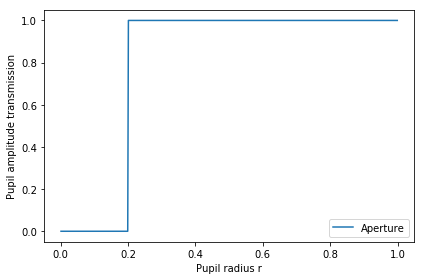

In [7]:
pl.figure(1)
pl.clf()
pl.plot(corono0.r, Pupil1d, label='Aperture')
pl.xlabel(r'Pupil radius r')
pl.ylabel('Pupil amplitude transmission')
pl.legend()
pl.tight_layout()
pl.show()


### Lyot Stop

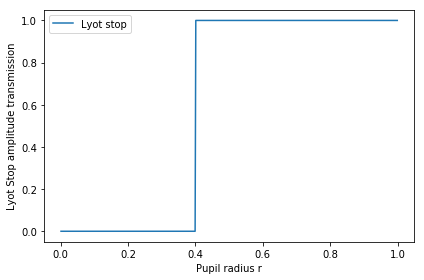

In [8]:
pl.figure(2)
pl.clf()
pl.plot(corono0.r, LyotStop1d, label='Lyot stop')
pl.xlabel(r'Pupil radius r')
pl.ylabel('Lyot Stop amplitude transmission')
pl.legend()
pl.tight_layout()
pl.show()

### Apodizer

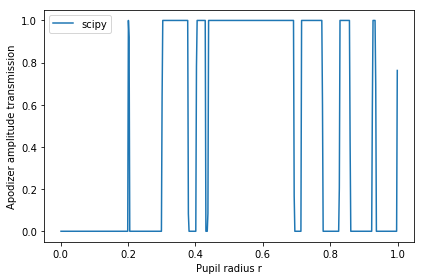

In [9]:
pl.figure(3)
pl.clf()
pl.plot(corono0.r, Apod_pyth/Apod_pyth.max(), label=solver)
pl.xlabel(r'Pupil radius r')
pl.ylabel('Apodizer amplitude transmission')
pl.legend()
pl.tight_layout()
pl.show()


## Computation of the direct and coronagraphic images

In [10]:
# fname_gen  = problem1.get_filename(nlam=nlambis)
params2    = coro.update_params(params, nlam=nlambis, nImg=nImgbis, Fmax=Fmaxbis) 

if corono_name == 'APLC':
    corono0 = coro.design.APLC1d(**params2)
elif corono_name == 'SP':
    corono0 = coro.design.SP1d(**params2)
elif corono_name == 'HDZPM':
    corono0 = coro.design.HDZPM1d(**params2)
elif corono_name == 'HTZPM':
    corono0 = coro.design.HTZPM1d(**params2)
else:
    raise NameError('{0}: Not an existing coronagraph!'.format(corono_name))

poly_direct_image1 = corono0.compute_direct_intensity_1d(Apod_pyth)
poly_corono_image1 = corono0.compute_corono_intensity_1d(Apod_pyth)

mono_direct_image1 = corono0.compute_direct_intensity_1d(Apod_pyth, poly=False)
mono_corono_image1 = corono0.compute_corono_intensity_1d(Apod_pyth, poly=False)

## Plot display of the intensity profiles of the coronagraphic images

###  Broadband light

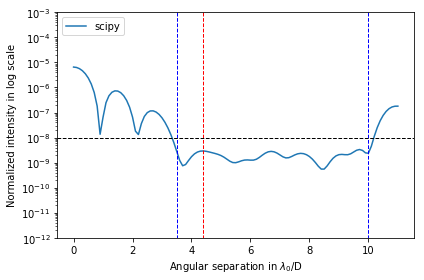

In [11]:
pl.figure(2)
pl.clf()
#pl.title('Intensity profiles of the coronagraphic images')
#pl.semilogy(corono0.xi,poly_direct_image1/poly_direct_image1.max(),label='Direct')
#pl.semilogy(corono0.xi,poly_direct_image2/poly_direct_image2.max(),label='Direct')
#pl.semilogy(corono0.xi,poly_direct_image3/poly_direct_image3.max(),label='Direct')
pl.semilogy(corono0.xi,poly_corono_image1/poly_direct_image1.max(),label=solver)
pl.axvline(x=corono0.rMask, ymin=-12, ymax =2, linewidth=1, color='r', linestyle='--')
pl.axvline(x=corono0.rho0, ymin=-12, ymax =2, linewidth=1, color='b', linestyle='--')
pl.axvline(x=corono0.rho1, ymin=-12, ymax =2, linewidth=1, color='b', linestyle='--')
pl.axhline(10**(-cDarkHole), xmin=corono0.xi.min(), xmax=corono0.xi.max(), linewidth=1, color='k', linestyle='--')
pl.xlabel(r'Angular separation in $\lambda_0$/D')
pl.ylabel('Normalized intensity in log scale')
pl.ylim(1e-12, 1e-3)
pl.legend()
pl.tight_layout()
pl.show()

### Monochromatic light

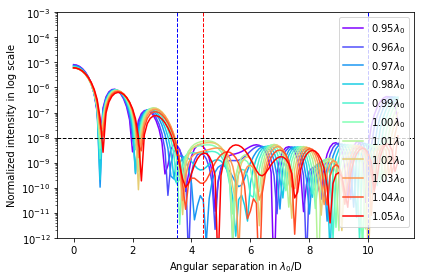

In [12]:
values = range(nlambis)
colors = pl.cm.rainbow(np.linspace(0,1,nlambis))

pl.figure(3)
pl.clf()
#pl.title('Intensity profiles of the coronagraphic images')
#pl.semilogy(corono0.xi,poly_direct_image1/poly_direct_image1.max(),label='Direct')
#pl.semilogy(corono0.xi,poly_direct_image2/poly_direct_image2.max(),label='Direct')
#pl.semilogy(corono0.xi,poly_direct_image3/poly_direct_image3.max(),label='Direct')
for i in range(corono0.nlam):
    pl.semilogy(corono0.xi,mono_corono_image1[i]/mono_direct_image1[(corono0.nlam+1)//2].max(), 
                label=r'{0:.2f}$\lambda_0$'.format(corono0.lam_t[i]), color = colors[i])
pl.axvline(x=corono0.rMask, ymin=-12, ymax =2, linewidth=1, color='r', linestyle='--')
pl.axvline(x=corono0.rho0, ymin=-12, ymax =2, linewidth=1, color='b', linestyle='--')
pl.axvline(x=corono0.rho1, ymin=-12, ymax =2, linewidth=1, color='b', linestyle='--')
pl.axhline(10**(-cDarkHole), xmin=corono0.xi.min(), xmax=corono0.xi.max(), linewidth=1, color='k', linestyle='--')
pl.xlabel(r'Angular separation in $\lambda_0$/D')
pl.ylabel('Normalized intensity in log scale')
pl.ylim(1e-12, 1e-3)
pl.legend()
pl.tight_layout()

pl.show()